In this notebook, I model my excitonic Hamiltonian as a Gaussian Unitary Ensemble (GUE) in order to shift to a more natural Hamiltonian and have a more holistic control knob for non-integrability.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from numpy.random import default_rng
from scipy.optimize import minimize_scalar
import matplotlib.cm as cm
import itertools
from itertools import combinations
from joblib import Parallel, delayed
import pickle
from mpl_toolkits.mplot3d import Axes3D
from scipy.optimize import root_scalar
from scipy.sparse.linalg import eigsh
from scipy.sparse import csr_matrix, lil_matrix
from collections import defaultdict
from scipy.sparse.linalg import expm_multiply
from scipy.linalg import svd
from scipy.optimize import curve_fit
from scipy.optimize import brentq
from scipy.linalg import logm, sqrtm, expm
from qutip import *

In [2]:
def generate_particle_basis(L, N):
    """All bitstrings of length L with exactly N ones (as ints)."""
    return [sum(1 << i for i in combo) for combo in itertools.combinations(range(L), N)]

def create_bosonic_H_GUE(L, num_particles=2, max_occupancy=None, scale=1.0, seed=None):
    """
    Create a Gaussian Unitary Ensemble (GUE) Hamiltonian in the bosonic basis.

    Parameters
    ----------
    L : int
        Number of lattice sites.
    num_particles : int
        Total number of bosons.
    max_occupancy : int or None
        Maximum occupancy per site (default: num_particles).
    scale : float
        Overall energy scale (sets the standard deviation of matrix elements).
    seed : int or None
        Random seed for reproducibility.

    Returns
    -------
    H : np.ndarray
        Hermitian random matrix (GUE) of shape (dim, dim).
    basis : list of tuples
        Bosonic Fock basis in same ordering as the Hamiltonian.
    """
    rng = np.random.default_rng(seed)
    basis = generate_particle_basis(L, N=2)
    dim = len(basis)

    # Generate a random complex matrix with independent Gaussian entries
    A = rng.normal(0, 1, (dim, dim)) + 1j * rng.normal(0, 1, (dim, dim))
    
    # Symmetrize to make it Hermitian (GUE condition)
    H = (A + A.conj().T) / 2.0

    # Normalize to desired scale (optional: ensure variance = scale^2 / dim)
    H *= scale / np.sqrt(dim)

    return H, basis

def reduced_density_matrix_general(rho, basis, keep_sites):
    """
    Optimized version of reduced_density_matrix_general that reduces memory and computational overhead.
    """
    dim_red = 2 ** len(keep_sites)
    rho_red = np.zeros((dim_red, dim_red), dtype=complex)

    # Precompute bit masks for keep sites
    keep_masks = [(1 << s) for s in keep_sites]
    trace_mask = sum(keep_masks)
    
    # Precompute index mapping
    index_map = {}
    for idx, state in enumerate(basis):
        keep_bits = [(state >> s) & 1 for s in keep_sites]
        red_idx = sum(b << i for i, b in enumerate(reversed(keep_bits)))
        trace_bits = state & ~trace_mask
        index_map[idx] = (trace_bits, red_idx)

    # Group by trace_bits
    groups = defaultdict(list)
    for idx, (trace_bits, _) in index_map.items():
        groups[trace_bits].append(idx)

    # Accumulate reduced density matrix elements
    for trace_bits, indices in groups.items():
        for i in indices:
            _, i_red = index_map[i]
            for j in indices:
                _, j_red = index_map[j]
                rho_red[i_red, j_red] += rho[i, j]

    return rho_red

def fidelity(rho1, rho2):
    sqrt_rho1 = sqrtm(rho1)
    return np.real(np.trace(sqrtm(sqrt_rho1 @ rho2 @ sqrt_rho1))**2)

def relative_entropy(rho1, rho2):
    return np.trace(rho1 @ (logm(rho1) - logm(rho2))).real

def trace_distance_calc(rho1, rho2):
    diff = rho1 - rho2
    s = svd(diff, compute_uv=False)
    return 0.5 * np.sum(np.abs(s))

def thermal_expectation_Hamiltonian(beta, evals):
    
    e_min = np.min(beta * evals)        # Shift energies to avoid overflow: numerical trick
    weights = np.exp(-(beta * evals - e_min))  # shifted exponent
    Z = np.sum(weights)
    thermal_E = np.sum(evals * weights) / Z
    return thermal_E

def find_beta_with_neg_temps(H, psi0, bracket=(-500, 500), plot=False):
    """Finds beta ∈ (−∞, ∞) such that thermal energy = ⟨ψ0|H|ψ0⟩."""
    E = np.vdot(psi0, H @ psi0).real
    evals, _ = np.linalg.eigh(H)

    def f(beta):
        return thermal_expectation_Hamiltonian(beta, evals) - E

    f_lo = f(bracket[0])
    f_hi = f(bracket[1])

    if np.sign(f_lo) == np.sign(f_hi):
        if plot:
            import matplotlib.pyplot as plt
            beta_vals = np.linspace(bracket[0], bracket[1], 500)
            thermal_vals = [thermal_expectation_Hamiltonian(b, evals) for b in beta_vals]
            plt.plot(beta_vals, thermal_vals, label="⟨H⟩_thermal(β)")
            plt.axhline(E, color='r', linestyle='--', label="E_init")
            plt.xlabel("β")
            plt.ylabel("Energy")
            plt.legend()
            plt.title("No root found: energy outside thermal range")
            plt.show()
        raise RuntimeError("No root in bracket: energy outside accessible thermal range.")

    beta_star = brentq(f, *bracket, xtol=1e-10)
    print(f"beta_star = {beta_star}")
    return beta_star, E 


In [3]:
# --- Setup ---
L = 20
keep_sites = [L // 2, L // 2 - 1, L // 2 + 1]
t_max = 20
num_samples = 50
times = np.linspace(0, t_max, num_samples)

# --- Hamiltonian and initial state ---
H, basis = create_bosonic_H_GUE(L=L, num_particles=2)                
evals, evecs = np.linalg.eigh(H)
psi0 = np.zeros(len(basis), dtype=complex)
psi0[0] = 1.0
proj_psi0 = evecs.T.conj() @ psi0

# --- Thermal state and reduced version ---
beta_star, _ = find_beta_with_neg_temps(H, psi0, bracket=(-100, 100))
weights = np.exp(-beta_star * evals)
weights /= np.sum(weights)
rho_thermal_full = (evecs * weights[np.newaxis, :]) @ evecs.conj().T
red_rho_thermal = reduced_density_matrix_general(rho_thermal_full, basis, keep_sites)

# --- Function to compute observables at a single time ---
def compute_observables(t):
    psi_t = evecs @ (np.exp(-1j * evals * t) * proj_psi0)
    rho_t = np.outer(psi_t, psi_t.conj())
    red_rho_t = reduced_density_matrix_general(rho_t, basis, keep_sites)

    D = trace_distance_calc(red_rho_t, red_rho_thermal)
    F = fidelity(red_rho_t, red_rho_thermal)
    S = relative_entropy(red_rho_t, red_rho_thermal)
    return D, 1 - F, S

# --- Parallel execution ---
results = Parallel(n_jobs=-1)(delayed(compute_observables)(t) for t in times)

# --- Unpack results ---
trace_distances_plain, infidelities_plain, rel_entropies_plain = map(list, zip(*results))

# 4m 9.1s

beta_star = 0.09243631406157149


/home/sameer/anaconda3/envs/quantum_algorithms/lib/python3.12/site-packages/scipy/linalg/_matfuncs.py:202: LogmExactlySingularWarning: The logm input matrix is exactly singular.
  F = scipy.linalg._matfuncs_inv_ssq._logm(A)
/home/sameer/anaconda3/envs/quantum_algorithms/lib/python3.12/site-packages/scipy/linalg/_matfuncs.py:202: LogmExactlySingularWarning: The logm input matrix is exactly singular.
  F = scipy.linalg._matfuncs_inv_ssq._logm(A)
/home/sameer/anaconda3/envs/quantum_algorithms/lib/python3.12/site-packages/scipy/linalg/_matfuncs.py:202: LogmExactlySingularWarning: The logm input matrix is exactly singular.
  F = scipy.linalg._matfuncs_inv_ssq._logm(A)
/home/sameer/anaconda3/envs/quantum_algorithms/lib/python3.12/site-packages/scipy/linalg/_matfuncs.py:202: LogmExactlySingularWarning: The logm input matrix is exactly singular.
  F = scipy.linalg._matfuncs_inv_ssq._logm(A)
/home/sameer/anaconda3/envs/quantum_algorithms/lib/python3.12/site-packages/scipy/linalg/_matfuncs.py:20

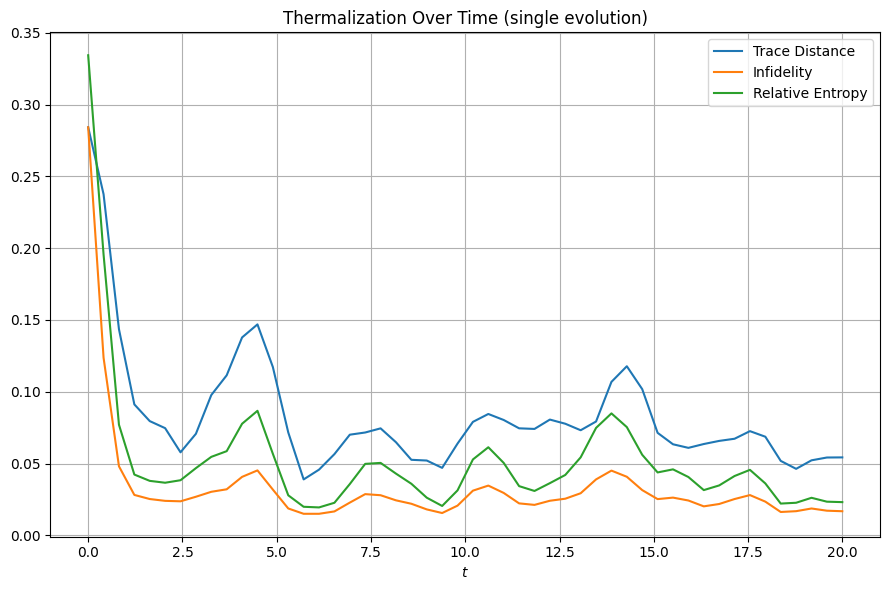

In [4]:
# --- Plotting ---
plt.figure(figsize=(9, 6))
plt.plot(times, trace_distances_plain, label='Trace Distance')
plt.plot(times, infidelities_plain, label='Infidelity')
plt.plot(times, rel_entropies_plain, label='Relative Entropy')
plt.xlabel(r'$t$')
plt.title('Thermalization Over Time (single evolution)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()
